# Haplosaurus

In [ ]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/grid/koo/home/schilder/projects/GenomeEncoder/')
import pandas as pd
import src.haplosaurus as hs
import src.variant_annotation as va
import src.ESM as ESM
import src.onekg as onekg
import src.utils as utils
import src.proteingym as pg
from src.config import DATA_DIR
from src.haplosaurus  import DIR_DICT


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'haplosaurus': '/grid/koo/home/schilder/projects/data/haplosaurus/',
 'vep': '/grid/koo/home/schilder/projects/data/haplosaurus/vep/',
 'haplotypes': '/grid/koo/home/schilder/projects/data/haplosaurus/haplotypes/',
 'variants': '/grid/koo/home/schilder/projects/data/haplosaurus/variants/',
 'variant_sets': '/grid/koo/home/schilder/projects/data/haplosaurus/variant_sets/',
 'variation': '/grid/koo/home/schilder/projects/data/haplosaurus/variation/'}

In [2]:
# %%R

# db = EnsDb.Hsapiens.v86::EnsDb.Hsapiens.v86
# # get the transcript to protein ID mappings
# txs <- GenomicFeatures::transcripts(db, columns = c("tx_id","protein_id"))
# txs <- txs[!is.na(txs$protein_id)]
# data.table::fwrite(data.frame(txs), "data/bioc/bioc_tx_to_prot.csv.gz")

## Get transcripts

In [3]:
# hs_db = hs.get_figshare("haplotype_analysis_database.zip")
# #  List all files in the directory
# hs_db_files = [f"{hs_db}/{x}" for x in os.listdir(hs_db)]
# hs_db_sql = [x for x in hs_db_files if x.endswith(".sql.gz")][0]
# hs_db_files
# import mysql.connector
# conn = mysql.connector.connect(
# host="localhost",
# user="root",
# password="root",
# database="haplotype_analysis_database"
# )
# cursor = conn.cursor() 

In [ ]:
# Haplosaurus protein IDs
tx_df = pd.read_excel(DATA_DIR + "haplosaurus/41467_2018_6542_MOESM4_ESM.xlsx")
print(tx_df.shape)
# Bioconductor transcript to protein ID
tx_to_prot = pd.read_csv(DATA_DIR + "bioc/bioc_tx_to_prot.csv.gz")
print(tx_to_prot.shape)
tx_df = tx_df.merge(tx_to_prot.drop_duplicates(subset=['tx_id', 'protein_id']),
                    left_on="Ensembl Protein ID", 
                    right_on="protein_id", 
                    how="inner") 
print(tx_df.shape)
tx_df.head()

(20166, 6)
(109705, 9)
(18494, 15)


/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3098: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Ensembl Gene ID,Ensembl Protein ID,Gene Name,Number of Haplotypes,Number of Haplotypes FoO>=1%,Frequency Rank of Reference Protein Haplotype,seqnames,start,end,width,strand,protein_id,uniprot_id,tx_biotype,tx_id
0,ENSG00000121410,ENSP00000263100,A1BG,44,3.0,2.0,19,58346850,58353499,6650,-,ENSP00000263100,P04217,protein_coding,ENST00000263100
1,ENSG00000148584,ENSP00000363107,A1CF,25,2.0,1.0,10,50806562,50885675,79114,-,ENSP00000363107,Q9NQ94,protein_coding,ENST00000373995
2,ENSG00000175899,ENSP00000323929,A2M,69,5.0,10.0,12,9067712,9116157,48446,-,ENSP00000323929,P01023,protein_coding,ENST00000318602
3,ENSG00000166535,ENSP00000299698,A2ML1,171,9.0,10.0,12,8822472,8876785,54314,+,ENSP00000299698,A8K2U0,protein_coding,ENST00000299698
4,ENSG00000184389,ENSP00000475261,A3GALT2,34,1.0,1.0,1,33306766,33321098,14333,-,ENSP00000475261,U3KPV4,protein_coding,ENST00000442999


<AxesSubplot:>

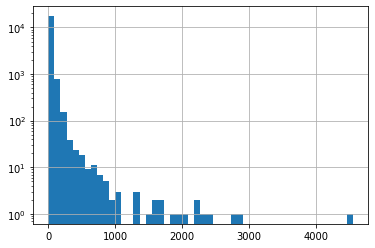

In [8]:
tx_df['Number of Haplotypes'].hist(bins=50, log=True)

In [9]:
# Remove MUC genes with lots of haplotypes as these may be artifacts
# tx_df = tx_df[(tx_df['Number of Haplotypes'] > 50) & (tx_df['Number of Haplotypes'] < 1000)]
# tx_df['Gene Name'].str.startswith('MUC')
tx_df.sort_values('Number of Haplotypes', ascending=False)
tx_ids = list(set(tx_df['tx_id'].tolist()))
tx_ids.reverse() # Start with the smallest number of haplotypes
# tx_ids = tx_ids[:5]

print(len(tx_ids),"transcripts")

18494 transcripts


## Get variant sets
Collect sets of variants (pathogenic, benign, 1KG) for each transcripts. 
Only trancripts with at least one pathogenic variant and one benign variant of the specifiied consequence type are included. Pathogenic/benign variants present in the 1KG cohort are excluded.

### Missense

In [10]:
variant_sets_dict = {
    ('SO:0001583','missense_variant'):{},
    ('SO:0001589','frameshift_variant'):{},
    ('SO:0001906','feature_truncation'):{}
    }

In [ ]:
for so_term, consequence_type in variant_sets_dict.keys():
    print(so_term, consequence_type)
    # Gather variant sets
    variant_sets_dict[(so_term, consequence_type)] = hs.get_variant_sets(
        tx_ids = tx_ids,
        so_term = so_term,
        consequence_type = consequence_type,
        # cache_only = cache_only, # Use cached files only (faster)
        error=False,
        # force=True
        )


SO:0001583 missense_variant
Found 6 descendants of 'missense_variant'
Found 6 descendants of 'SO:0001583'


Gathering variant sets:   0%|          | 0/18494 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/8 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/304 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/1 [00:00<?, ?it/s]

...

Filtering variants:   0%|          | 0/89 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/8 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/6 [00:00<?, ?it/s]

ENST00000318158: Annotating pathogenic variants:   0%|          | 0/8 [00:00<?, ?it/s]

: 

In [21]:
# Get the number of transcripts with variant sets per consequence type
{k:len(v) for k,v in variant_sets_dict.items()}

{('SO:0001583', 'missense_variant'): 1070,
 ('SO:0001589', 'frameshift_variant'): 0,
 ('SO:0001906', 'feature_truncation'): 0}

## Get haplotypes


In [14]:
haplotypes = hs.get_haplotypes(
    tx_ids=tx_ids, #variant_sets.keys(),
    save_dir="data/haplosaurus/haplotypes",
    species="homo_sapiens",
    params={'samples':1,
            'sequence':1,
            'aligned_sequences':1},
    cache_only=True, # Use cached files only (faster)
    force=False
    )


Getting haplotypes:   0%|          | 0/3380 [00:00<?, ?it/s]

## Get reference haplotypes

In [15]:
haplotypes_ref = hs.get_haplotype_ref(haplotypes)
haplotypes_ref_seqs, missing_seqs = hs.get_haplotype_seqs(
    haplotypes_ref,
    return_missing=True,
    verbose=True)
(len(haplotypes), 
 len(haplotypes_ref), 
 len(haplotypes_ref_seqs),
 len(missing_seqs))


Processing transcripts:   0%|          | 0/402 [00:00<?, ?it/s]

  0%|          | 0/402 [00:00<?, ?it/s]

No seqs found for ENST00000359568
No seqs found for ENST00000324093
No seqs found for ENST00000405460
No seqs found for ENST00000354785


(402, 402, 398, 4)

## Add variants to haplotypes

In [16]:
haplotypes_wt, haplotypes_pathogenic, haplotypes_benign = hs.add_variant_to_haplotypes(
  haplotypes=haplotypes, 
  variant_sets=variant_sets, 
  tx_ids=tx_ids,
  consequence_terms=['missense_variant'],
  max_transcripts=5,
  ref_checks=False,
  verbose=True
  )
# check length of each group
len(haplotypes_wt), len(haplotypes_pathogenic), len(haplotypes_benign)

Adding variants to transcript haplotypes:   0%|          | 0/5 [00:00<?, ?it/s]

Filtering variants:   0%|          | 0/1 [00:00<?, ?it/s]

Getting pathogenic variant VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Filtering variants VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Adding pathogenic variants to haplotypes:   0%|          | 0/122 [00:00<?, ?it/s]

...

Filtering variants:   0%|          | 0/8 [00:00<?, ?it/s]

Getting benign variant VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Filtering variants VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Adding benign variants to haplotypes:   0%|          | 0/57 [00:00<?, ?it/s]

(5, 5, 5)

In [17]:
print(hs.get_haplotype_counts(haplotypes_wt))
print(hs.get_haplotype_counts(haplotypes_pathogenic))
print(hs.get_haplotype_counts(haplotypes_benign))


{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
